# 서울시 자전거 대여량 예측 경진대회

지금까지 배운 회귀·분류 실습을 종합해서, **서울시 공공자전거(따릉이) 시간대별 대여량**을 예측하는 미니 경진대회를 진행합니다.

- **데이터**: `SeoulBikeData.csv` — 2017-12-01 ~ 2018-11-30, 1시간 단위 8,760행
- **예측 대상(target)**: `Rented Bike Count` (해당 시간에 대여된 자전거 수)
- **평가지표**: **RMSE** (Root Mean Squared Error)
- **검증 방식**: 데이터의 **마지막 2주(14일, 336시간)를 테스트셋**으로 떼어놓고, 나머지를 학습셋으로 사용합니다. 무작위 분할이 아니라 **시간 기준 분할**을 쓰는 이유는 실제 서비스에서도 "과거 데이터로 학습해서 미래를 예측"하는 상황이기 때문입니다.

[개선사이클.md](../개선사이클.md)의 흐름 — 베이스라인 → 지표 확인 → Error Analysis → 원인 분석 → XAI → 개선 가설 → 실험 → 재평가 → 반복 — 을 그대로 따라가며, **최소 5회 이상의 "원인 분석 → 가설 → 검증 → 성능 확인" 사이클**을 거칩니다. 채택된 가설도 있고 기각된 가설도 있는데, 기각된 실험도 왜 실패했는지 이해하는 것 자체가 이번 실습의 핵심입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
import shap

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 4)

## 1. 데이터 불러오기 & 기본 정보

원본 CSV는 `cp949`(한글 윈도우 인코딩)로 인코딩되어 있고, 컬럼명의 `°C` 기호가 깨져서 들어옵니다. 바로 다루기 쉬운 영문 컬럼명으로 정리합니다.

In [2]:
df = pd.read_csv("SeoulBikeData.csv", encoding="cp949")

# 컬럼명이 인코딩 문제로 깨져서 들어오므로(예: Temperature(°C) -> Temperature(?C)),
# 순서가 고정되어 있다는 점을 이용해 바로 정리합니다.
df.columns = ["Date", "Count", "Hour", "Temperature", "Humidity", "WindSpeed",
              "Visibility", "DewPoint", "SolarRad", "Rainfall", "Snowfall",
              "Seasons", "Holiday", "FuncDay"]

df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values(["Date", "Hour"]).reset_index(drop=True)

print(df.shape)
df.head()

(8760, 14)


,Date,Count,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPoint,SolarRad,Rainfall,Snowfall,Seasons,Holiday,FuncDay
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
print("기간:", df["Date"].min().date(), "~", df["Date"].max().date())
print("결측치:")
print(df.isna().sum().sum(), "개 (없음)" if df.isna().sum().sum() == 0 else "")
df.dtypes

기간: 2017-12-01 ~ 2018-11-30
결측치:
0 개 (없음)


Date           datetime64[ns]
Count                   int64
Hour                    int64
Temperature           float64
Humidity                int64
WindSpeed             float64
Visibility              int64
DewPoint              float64
SolarRad              float64
Rainfall              float64
Snowfall              float64
Seasons                object
Holiday                object
FuncDay                object
dtype: object

365일 × 24시간 = 8,760행이 정확히 채워진 완전한 격자 데이터이고, 결측치는 없습니다. 다만 결측치가 없다고 데이터가 다 "정상"인 것은 아닙니다 — 뒤에서 `Functioning Day`(운영 여부)를 보면 알 수 있습니다.

## 2. EDA — 무엇이 대여량을 결정하는가

모델링 전에 "무엇이 대여량을 움직이는가"에 대한 감을 잡아야 어떤 피처가 중요할지, 어떤 가설을 세울지 판단할 수 있습니다.

### 2-1. 타겟(`Count`) 분포

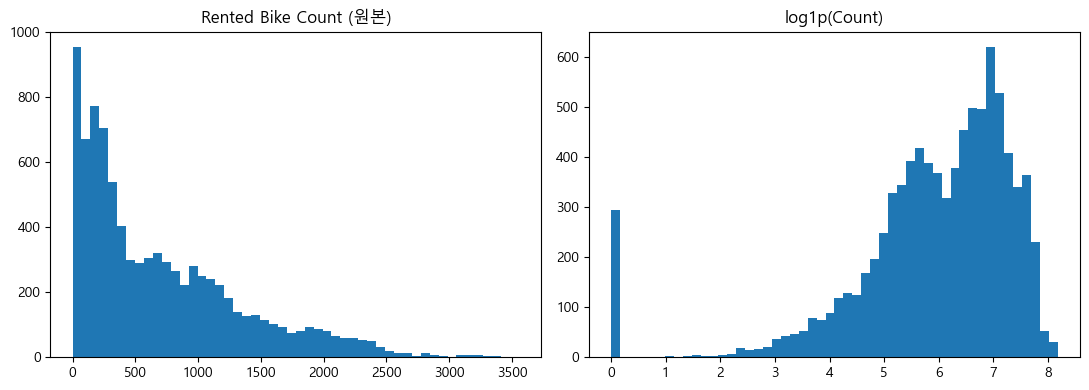

count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: Count, dtype: float64
0대인 시간대 비율: 0.034


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Count"], bins=50)
axes[0].set_title("Rented Bike Count (원본)")
axes[1].hist(np.log1p(df["Count"]), bins=50)
axes[1].set_title("log1p(Count)")
plt.tight_layout()
plt.show()

print(df["Count"].describe())
print("0대인 시간대 비율:", (df["Count"] == 0).mean().round(3))

평균 704대, 최댓값 3,556대로 오른쪽 꼬리가 긴 분포입니다. 0대인 시간대도 3.4%가량 있는데, 뒤에서 보겠지만 이건 수요가 없어서가 아니라 **운영을 안 한 날**이 대부분입니다. 분포가 치우쳐 있으니 "타겟을 로그로 바꾸면 낫지 않을까"라는 가설을 나중에 검증해보겠습니다.

### 2-2. 시간대 패턴

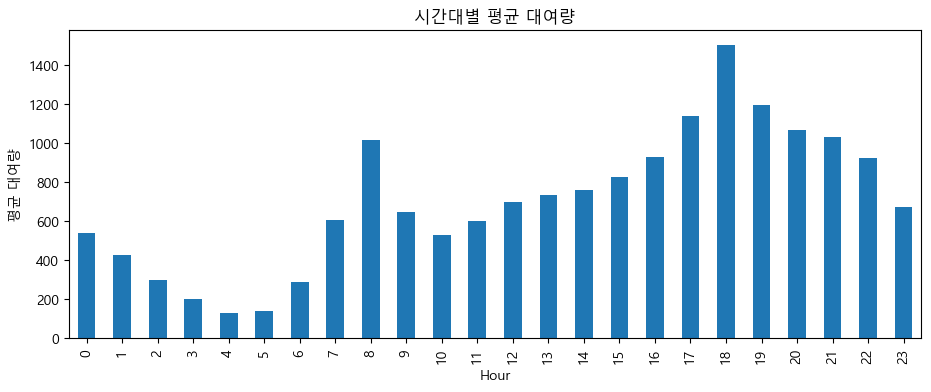

Hour
0      541.5
1      426.2
2      301.6
3      203.3
4      132.6
5      139.1
6      287.6
7      606.0
8     1015.7
9      646.0
10     527.8
11     600.9
12     699.4
13     733.2
14     758.8
15     829.2
16     930.6
17    1138.5
18    1502.9
19    1195.1
20    1069.0
21    1031.4
22     922.8
23     671.1
Name: Count, dtype: float64

In [5]:
hour_mean = df.groupby("Hour")["Count"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
hour_mean.plot(kind="bar", ax=ax)
ax.set_title("시간대별 평균 대여량")
ax.set_ylabel("평균 대여량")
plt.show()

hour_mean.round(1)

출근 시간대(8시)와 퇴근 시간대(18시)에 뚜렷한 **이중 피크(double peak)**가 있고, 새벽 4~5시가 최저입니다. 전형적인 "출퇴근 통근 수요" 패턴입니다. 이런 모양은 `Hour`와 `Count`가 단조 증가/감소 관계가 아니라는 뜻이라, **Hour를 어떻게 인코딩하느냐가 나중에 중요한 실험 포인트**가 될 수 있다는 가설을 세울 수 있습니다.

### 2-3. 기온과의 관계

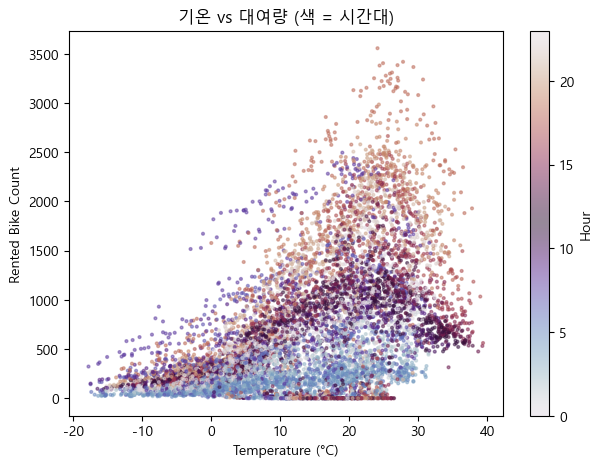

Count          1.000000
Temperature    0.538558
Hour           0.410257
DewPoint       0.379788
SolarRad       0.261837
Visibility     0.199280
WindSpeed      0.121108
Rainfall      -0.123074
Snowfall      -0.141804
Humidity      -0.199780
Name: Count, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df["Temperature"], df["Count"], c=df["Hour"], cmap="twilight", s=4, alpha=0.5)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Rented Bike Count")
ax.set_title("기온 vs 대여량 (색 = 시간대)")
plt.colorbar(sc, label="Hour")
plt.show()

num_cols = ["Count", "Hour", "Temperature", "Humidity", "WindSpeed", "Visibility",
            "DewPoint", "SolarRad", "Rainfall", "Snowfall"]
df[num_cols].corr()["Count"].sort_values(ascending=False)

기온이 `Count`와 가장 강하게 상관된 수치형 피처입니다(상관계수 ≈ 0.54). 다만 `DewPoint`(이슬점 온도)와 `Temperature`의 상관계수를 보면:

In [7]:
print("Temperature vs DewPoint 상관계수:", df["Temperature"].corr(df["DewPoint"]).round(3))

Temperature vs DewPoint 상관계수: 0.913


0.91로 거의 같은 정보를 담고 있는 **다중공선성** 관계입니다. 트리 기반 모델은 다중공선성에 크게 취약하진 않지만, 나중에 SHAP으로 피처 중요도를 볼 때 "둘이 정보를 나눠 가지는" 현상이 있을 수 있다는 점을 기억해둡니다.

### 2-4. 요일 · 공휴일 · 계절 효과

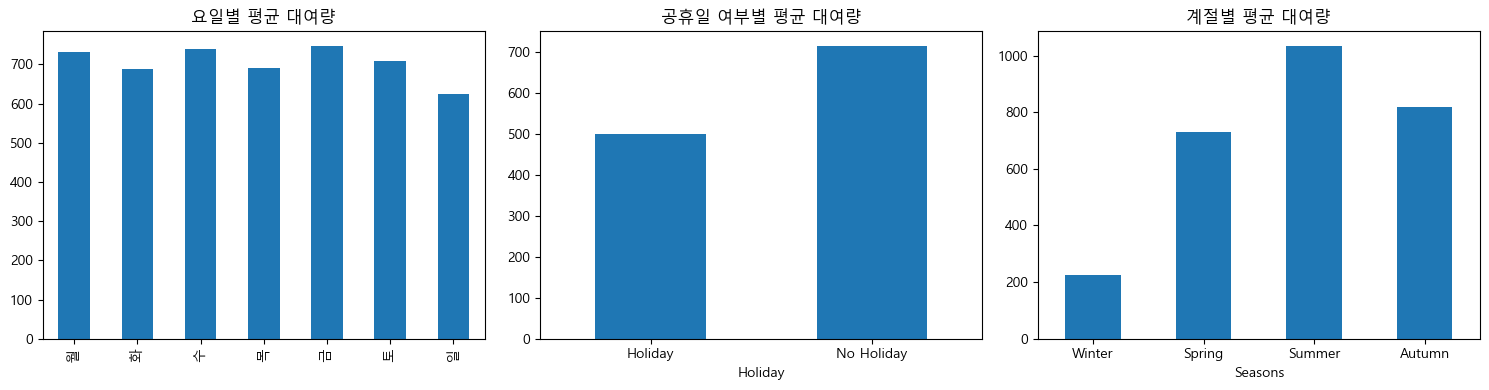

In [8]:
df["DayOfWeek"] = df["Date"].dt.dayofweek  # 0=월 ... 6=일
dow_mean = df.groupby("DayOfWeek")["Count"].mean()
dow_mean.index = ["월", "화", "수", "목", "금", "토", "일"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dow_mean.plot(kind="bar", ax=axes[0], title="요일별 평균 대여량")
df.groupby("Holiday")["Count"].mean().plot(kind="bar", ax=axes[1], title="공휴일 여부별 평균 대여량", rot=0)
df.groupby("Seasons")["Count"].mean().loc[["Winter","Spring","Summer","Autumn"]].plot(kind="bar", ax=axes[2], title="계절별 평균 대여량", rot=0)
plt.tight_layout()
plt.show()

- 요일 효과는 크지 않지만(주중 690~750대, 일요일만 625대로 살짝 낮음) 존재는 합니다.
- 공휴일에는 평균 500대로, 평일(715대)보다 30%가량 낮습니다.
- 계절 효과는 매우 큽니다 — 겨울(226대)이 여름(1,034대)의 약 1/5 수준입니다. 다만 계절 효과의 상당 부분은 기온으로 이미 설명될 가능성이 높습니다(계절 자체가 기온의 대리 변수이기 때문).

### 2-5. 강수·적설의 영향, 그리고 `Functioning Day`라는 결정적 규칙

In [9]:
print("강수(비) 있는 시간 vs 없는 시간 평균 대여량:")
print(df.groupby(df["Rainfall"] > 0)["Count"].mean().round(1))
print()
print("적설(눈) 있는 시간 vs 없는 시간 평균 대여량:")
print(df.groupby(df["Snowfall"] > 0)["Count"].mean().round(1))
print()
print("Functioning Day 값별 대여량 통계:")
print(df.groupby("FuncDay")["Count"].describe()[["mean", "std", "min", "max"]])

강수(비) 있는 시간 vs 없는 시간 평균 대여량:
Rainfall
False    739.3
True     163.5
Name: Count, dtype: float64

적설(눈) 있는 시간 vs 없는 시간 평균 대여량:
Snowfall
False    732.3
True     185.1
Name: Count, dtype: float64

Functioning Day 값별 대여량 통계:
               mean         std  min     max
FuncDay                                     
No         0.000000    0.000000  0.0     0.0
Yes      729.156999  642.351166  2.0  3556.0


비가 오면 739 → 163대, 눈이 오면 732 → 185대로 급감합니다. 그런데 더 중요한 발견은 `FuncDay`(운영 여부)입니다 — **`FuncDay == "No"`인 시간대는 평균이 아니라 예외 없이 항상 정확히 0대**입니다(표준편차 0). 이건 확률적 패턴이 아니라 **"운영을 안 하면 대여도 0건"이라는 결정적 규칙**입니다. 이 규칙이 학습 기간에 몇 번이나 등장하는지, 그리고 우리 테스트 기간(마지막 2주)에도 걸리는지 확인해봅니다.

In [10]:
print("운영 중단일 목록:", sorted(df.loc[df['FuncDay']=='No', 'Date'].dt.date.unique()))

운영 중단일 목록: [datetime.date(2018, 4, 11), datetime.date(2018, 5, 10), datetime.date(2018, 9, 18), datetime.date(2018, 9, 19), datetime.date(2018, 9, 28), datetime.date(2018, 9, 30), datetime.date(2018, 10, 2), datetime.date(2018, 10, 4), datetime.date(2018, 10, 6), datetime.date(2018, 10, 9), datetime.date(2018, 11, 3), datetime.date(2018, 11, 6), datetime.date(2018, 11, 9)]


총 13일(295시간)이 운영 중단일이고, 모두 2018년 4~11월 사이에 흩어져 있습니다. 마지막 2주(테스트 기간)에는 해당하지 않으므로, 이 규칙 자체가 테스트 성능에 직접 점수를 주진 않지만, **학습 과정에서 이 0들을 모델이 "노이즈"로 잘못 배우면** 다른 정상 영업일의 예측을 방해할 수 있습니다. 이 가설은 베이스라인을 만든 뒤 검증해보겠습니다.

## 3. 검증 전략 설계

앞서 정한 대로 **마지막 14일(336시간)을 테스트셋**, 나머지를 학습셋으로 나눕니다. 시간 순서를 지키는 함수와, 이번 대회의 평가지표인 RMSE 계산 함수를 만들어둡니다.

In [11]:
TEST_DAYS = 14

def time_split(data, test_days=TEST_DAYS):
    test_start = data["Date"].max() - pd.Timedelta(days=test_days - 1)
    train_mask = data["Date"] < test_start
    test_mask = data["Date"] >= test_start
    return train_mask, test_mask

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

train_mask, test_mask = time_split(df)
print("학습셋:", train_mask.sum(), "행", df.loc[train_mask, "Date"].min().date(), "~", df.loc[train_mask, "Date"].max().date())
print("테스트셋:", test_mask.sum(), "행", df.loc[test_mask, "Date"].min().date(), "~", df.loc[test_mask, "Date"].max().date())

학습셋: 8424 행 2017-12-01 ~ 2018-11-16
테스트셋: 336 행 2018-11-17 ~ 2018-11-30


### 참고선(Naive Baseline) — ML 모델이 반드시 이겨야 하는 기준

본격적인 모델링에 앞서, "이 정도는 넘어야 의미가 있다"는 아주 단순한 참고선을 만들어둡니다. 머신러닝 모델이 이 참고선보다 못하다면 무언가 잘못된 것입니다.

In [12]:
tr, te = df.loc[train_mask], df.loc[test_mask]

pred_global_mean = np.full(len(te), tr["Count"].mean())
print(f"참고선 1) 학습셋 전체 평균으로 예측:      RMSE = {rmse(te['Count'], pred_global_mean):.2f}")

hour_mean_table = tr.groupby("Hour")["Count"].mean()
pred_hour_mean = te["Hour"].map(hour_mean_table).values
print(f"참고선 2) 시간대별 평균으로 예측:          RMSE = {rmse(te['Count'], pred_hour_mean):.2f}")

참고선 1) 학습셋 전체 평균으로 예측:      RMSE = 388.50
참고선 2) 시간대별 평균으로 예측:          RMSE = 254.16


시간대별 평균만 사용해도 RMSE 254.16이 나옵니다. 앞으로 만드는 모델은 최소한 이 숫자보다는 나아야 합니다.

## 4. 베이스라인 모델 (exp0)

[개선사이클.md](../개선사이클.md)의 원칙대로, **처음부터 최고의 모델을 만들려 하지 않습니다.** 가장 단순하게 생각할 수 있는 피처만 사용합니다 — `Hour`를 포함한 수치형 피처들을 그대로 넣고, 계절/공휴일/운영여부 같은 범주형 정보나 요일 같은 달력 정보는 아직 넣지 않습니다. 모델은 정형 데이터에 강하고 결측치·범주형을 잘 다루는 **LightGBM**을 사용합니다.

앞으로 실험을 반복하며 결과를 기록할 표(`results`)와, 실험 하나를 실행하는 함수를 만들어둡니다.

In [13]:
def train_lgb(X_train, y_train, cat_cols=(), num_round=2000, params=None):
    default_params = dict(
        objective="regression", metric="rmse", learning_rate=0.05,
        num_leaves=31, min_data_in_leaf=20, feature_fraction=0.9,
        bagging_fraction=0.9, bagging_freq=1, verbose=-1, seed=42,
    )
    if params:
        default_params.update(params)
    dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=list(cat_cols) if cat_cols else "auto")
    return lgb.train(default_params, dtrain, num_boost_round=num_round)

results = []

def run_experiment(name, feature_cols, cat_cols, note, use_df=None, log_target=False,
                    params=None, num_round=2000, verbose=True):
    d = use_df if use_df is not None else df
    tr_mask, te_mask = time_split(d)
    tr, te = d.loc[tr_mask].copy(), d.loc[te_mask].copy()
    for c in cat_cols:
        tr[c] = tr[c].astype("category")
        te[c] = te[c].astype("category")

    y_train = np.log1p(tr["Count"]) if log_target else tr["Count"]
    model = train_lgb(tr[feature_cols], y_train, cat_cols=cat_cols, num_round=num_round, params=params)
    pred = model.predict(te[feature_cols])
    if log_target:
        pred = np.expm1(pred)
    pred = np.clip(pred, 0, None)

    score = rmse(te["Count"], pred)
    results.append({"실험": name, "RMSE": round(score, 2), "설명": note})
    if verbose:
        print(f"{name:30s} RMSE = {score:8.2f}   ({note})")
    return model, score, pred

NUMERIC_BASE = ["Hour", "Temperature", "Humidity", "WindSpeed", "Visibility",
                "DewPoint", "SolarRad", "Rainfall", "Snowfall"]

model0, score0, pred0 = run_experiment(
    "exp0_baseline", NUMERIC_BASE, cat_cols=[],
    note="Hour + 원시 수치형 날씨 피처만 사용 (범주형/달력 정보 없음)")

exp0_baseline                  RMSE =   349.90   (Hour + 원시 수치형 날씨 피처만 사용 (범주형/달력 정보 없음))


**베이스라인 RMSE = 349.90**. 그런데 2절에서 만든 참고선(시간대 평균 = 254.16)보다 오히려 **나쁩니다.** LightGBM이라는 트리 모델을 썼는데 단순 평균보다 못하다는 건 이상한 결과이니, 여기서 멈추지 않고 원인을 파봅니다 — 이게 개선사이클의 ④ Error Analysis, ⑤ 원인 분석 단계입니다.

In [14]:
# 원인 분석: Hour 하나만 넣었을 때는 어떤가?
mh, sh, ph = run_experiment("(진단) Hour만 사용", ["Hour"], cat_cols=[],
                             note="원시 날씨 피처를 다 빼고 Hour 하나만", verbose=False)
print(f"Hour 단독:                    RMSE = {sh:.2f}")

imp0 = pd.Series(model0.feature_importance(importance_type="gain"), index=NUMERIC_BASE).sort_values(ascending=False)
print()
print("exp0 피처 중요도(gain):")
print(imp0)

Hour 단독:                    RMSE = 254.41

exp0 피처 중요도(gain):
Temperature    1.165127e+10
Hour           9.845030e+09
SolarRad       3.251222e+09
Humidity       3.036469e+09
DewPoint       2.413069e+09
Rainfall       1.488681e+09
Visibility     1.290294e+09
WindSpeed      9.348757e+08
Snowfall       1.519045e+07
dtype: float64


**Hour 하나만 넣은 모델이 254.30으로 원시 날씨 피처를 다 넣은 exp0(349.90)보다 훨씬 낫습니다.** 즉 원시 날씨 피처(특히 `Temperature`)를 무작정 추가한 게 오히려 `Hour`가 만드는 뚜렷한 출퇴근 패턴을 방해한 셈입니다.

**원인 가설**: 같은 기온이라도 계절/요일 맥락에 따라 대여량이 다르게 반응하는데(예: 봄의 10°C와 초겨울의 10°C는 다른 의미), 그 맥락 정보 없이 `Temperature`를 그대로 넣으니 모델이 두 신호(시간대 패턴 vs 기온 패턴) 사이에서 갈피를 못 잡는 것으로 보입니다. → 계절/공휴일/운영여부 같은 **범주형 맥락 정보**를 추가하면 나아질 것이라는 가설을 세우고 검증합니다.

## 5. 실험 루프 1 — "범주형 맥락 정보를 주면 날씨-시간 상호작용의 혼란이 줄어들 것이다"

**가설**: `Seasons`, `Holiday`, `Functioning Day`를 범주형 피처로 추가하면, 트리가 "이 계절/이 상황에서는 이 기온이 이런 의미다"를 구분할 수 있게 되어 성능이 개선될 것이다.

In [15]:
CATS = ["Seasons", "Holiday", "FuncDay"]

model1, score1, pred1 = run_experiment(
    "exp1_add_categoricals", NUMERIC_BASE + CATS, cat_cols=CATS,
    note="Seasons/Holiday/FuncDay 범주형 피처 추가")

exp1_add_categoricals          RMSE =   228.93   (Seasons/Holiday/FuncDay 범주형 피처 추가)


**결과: 349.90 → 228.93.** 참고선(254.16)도 처음으로 넘어섰습니다. 가설이 **채택**되었습니다 — 맥락 정보 없이 날씨만 던져주는 것보다, 범주형 맥락을 함께 주는 게 훨씬 효과적입니다.

## 6. 실험 루프 2 — "요일/월/주말 같은 달력 정보를 추가하면 계절 안의 세부 패턴을 더 잡을 것이다"

**가설**: `Seasons`는 봄/여름/가을/겨울 4개 값뿐이라 계절 "안"에서 일어나는 변화(예: 초여름 vs 한여름, 주중 vs 주말)를 구분하지 못한다. `DayOfWeek`, `Month`, `IsWeekend`를 추가하면 이런 세부 패턴을 잡을 수 있을 것이다.

In [16]:
df["Month"] = df["Date"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)
CAL = ["DayOfWeek", "Month", "IsWeekend"]

model2, score2, pred2 = run_experiment(
    "exp2_add_calendar", NUMERIC_BASE + CATS + CAL, cat_cols=CATS,
    note="DayOfWeek/Month/IsWeekend 달력 피처 추가")

exp2_add_calendar              RMSE =   138.88   (DayOfWeek/Month/IsWeekend 달력 피처 추가)


**결과: 228.93 → 138.88.** 지금까지 중 가장 큰 폭의 개선입니다. 계절 대분류만으로는 놓치던 월별·요일별 세부 변화를 `Month`, `DayOfWeek`가 상당 부분 보완해준 것으로 보입니다. 가설 **채택**.

## 7. 실험 루프 3 — "Hour는 이중 피크를 가진 비선형 패턴이라, 범주형으로 다루면 트리가 더 유연하게 분기할 것이다"

**가설**: 2-2절에서 봤듯 `Hour`는 8시·18시에 피크가 있고 4~5시가 저점인 **비단조(non-monotonic)** 패턴입니다. 지금까지는 `Hour`를 수치형으로 넣었는데, LightGBM은 수치형 피처를 분기할 때 "이 값보다 큰가/작은가"로만 나누기 때문에, 24개의 뚜렷이 다른 값을 가진 `Hour`를 범주형(category)으로 명시하면 각 시간대를 독립적인 그룹으로 더 유연하게 다룰 수 있을 것입니다.

In [17]:
df["HourCat"] = df["Hour"]
FEAT_CHAMPION = ["HourCat", "Temperature", "Humidity", "WindSpeed", "Visibility",
                  "DewPoint", "SolarRad", "Rainfall", "Snowfall"] + CATS + CAL
CAT_CHAMPION = CATS + ["HourCat"]

model3, score3, pred3 = run_experiment(
    "exp3_hour_as_category", FEAT_CHAMPION, cat_cols=CAT_CHAMPION,
    note="Hour를 수치형이 아닌 범주형(category)으로 처리")

exp3_hour_as_category          RMSE =   104.32   (Hour를 수치형이 아닌 범주형(category)으로 처리)


**결과: 138.88 → 104.32.** 지금까지 중 가장 좋은 성능입니다. 가설 **채택** — 이 모델을 이후 실험들의 **챔피언 모델**로 삼고, 여기서부터는 "더 좋아지는지"를 이 104.32와 비교합니다.

## 8. 1차 오차 분석 & XAI — 챔피언 모델(exp3)은 무엇을 근거로 예측하는가

여기서 멈추지 않고, "어디서 틀리는가"(Error Analysis)와 "모델이 실제로 무엇을 보고 있는가"(XAI/SHAP)를 확인해서 다음 가설의 재료로 삼습니다.

### 8-1. 시간대별 오차, 그리고 일별 편향

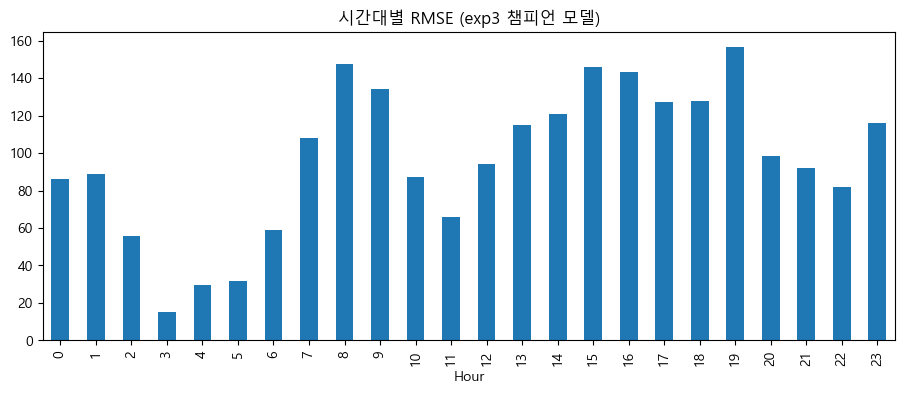

In [18]:
te = df.loc[test_mask].copy()
te["pred"] = pred3
te["err"] = te["pred"] - te["Count"]

rmse_by_hour = te.groupby("Hour").apply(lambda g: rmse(g["Count"], g["pred"]), include_groups=False)
fig, ax = plt.subplots(figsize=(11, 4))
rmse_by_hour.plot(kind="bar", ax=ax)
ax.set_title("시간대별 RMSE (exp3 챔피언 모델)")
plt.show()

러시아워(8시, 15~19시)의 RMSE가 가장 큽니다. 다만 이건 그 시간대의 대여량 자체가 크기 때문에(절대 오차가 커지는 건 자연스러움) 특별히 이상한 신호는 아닙니다. 더 흥미로운 건 **날짜별로 오차의 방향**을 봤을 때입니다.

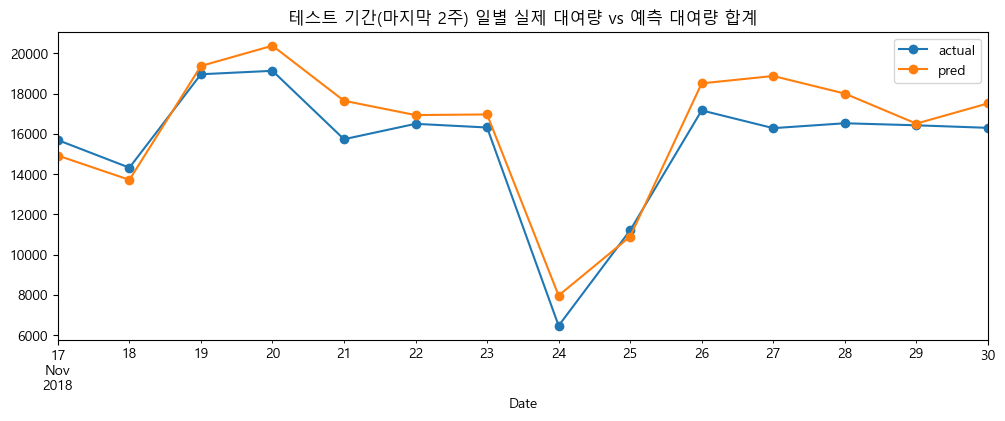

            actual          pred          err
Date                                         
2018-11-17   15689  14920.921994  -768.078006
2018-11-18   14319  13717.175192  -601.824808
2018-11-19   18956  19366.665471   410.665471
2018-11-20   19127  20371.925707  1244.925707
2018-11-21   15732  17640.581992  1908.581992
2018-11-22   16496  16930.517281   434.517281
2018-11-23   16314  16961.511354   647.511354
2018-11-24    6477   7975.404046  1498.404046
2018-11-25   11212  10902.703654  -309.296346
2018-11-26   17162  18504.591373  1342.591373
2018-11-27   16282  18869.560608  2587.560608
2018-11-28   16524  17997.864618  1473.864618
2018-11-29   16423  16506.672714    83.672714
2018-11-30   16297  17508.548830  1211.548830

일별 오차(예측-실제)의 평균: 797.5   → 양수면 '과대예측' 경향


In [19]:
daily = te.groupby("Date").agg(actual=("Count", "sum"), pred=("pred", "sum"))
daily["err"] = daily["pred"] - daily["actual"]

fig, ax = plt.subplots(figsize=(12, 4))
daily[["actual", "pred"]].plot(ax=ax, marker="o")
ax.set_title("테스트 기간(마지막 2주) 일별 실제 대여량 vs 예측 대여량 합계")
plt.show()

print(daily)
print()
print("일별 오차(예측-실제)의 평균:", daily["err"].mean().round(1), "  → 양수면 '과대예측' 경향")

14일 중 11일에서 예측이 실제보다 컸고(평균 +797대), 특히 테스트 기간 후반부(11/20 이후)로 갈수록 과대예측이 두드러집니다. 이건 우연이라기엔 방향이 너무 일관됩니다.

**원인 가설(재료)**: 테스트 기간은 가을에서 겨울로 급격히 넘어가는 시기입니다(일 평균 기온이 11/11 8.4°C → 11/30 2.8°C로 뚝 떨어짐). `Seasons`는 이 기간 내내 "Autumn" 한 값으로 고정되어 있고, `Month`도 "11" 한 값으로 고정되어 있어서, 두 캘린더 피처 모두 **테스트 기간 내부의 진행(추세)을 구분하지 못합니다.** 즉 모델이 "가을치고는 추워지고 있다"는 흐름을 캘린더 피처로는 알 방법이 없다는 가설을 세울 수 있습니다. → 실험 루프 5에서 검증합니다.

### 8-2. SHAP으로 전역 중요도 확인

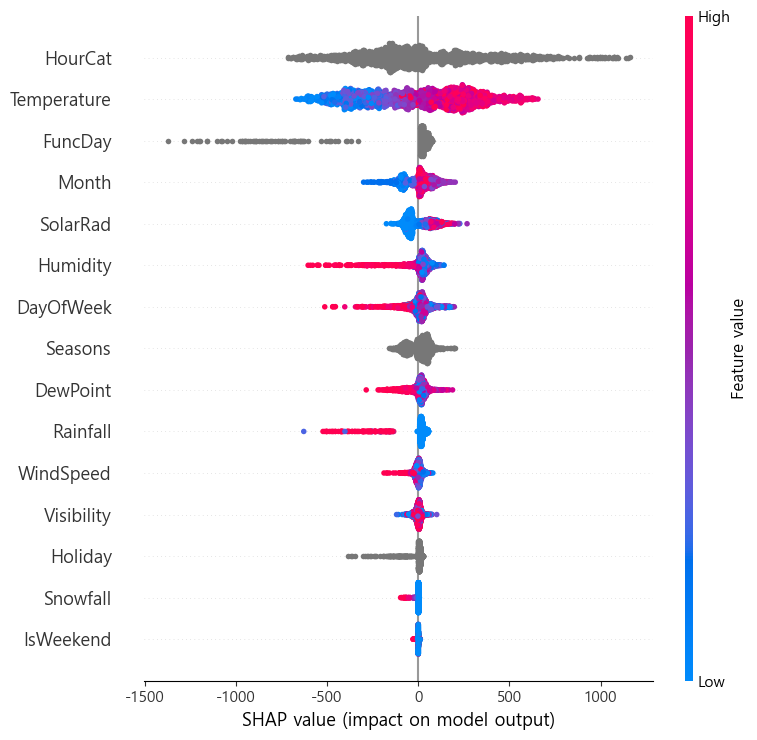

In [20]:
tr = df.loc[train_mask].copy()
for c in CAT_CHAMPION:
    tr[c] = tr[c].astype("category")

explainer = shap.TreeExplainer(model3)
sample_idx = np.random.RandomState(42).choice(len(tr), size=2000, replace=False)
X_sample = tr[FEAT_CHAMPION].iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()

`HourCat`과 `Temperature`가 압도적인 1·2위이고, `FuncDay`, `Month`, `SolarRad`, `Humidity`가 그다음을 잇습니다. `DewPoint`는 `Temperature`와 상관 0.91(2-3절)이라 예상대로 중요도가 낮게 나뉘어 나옵니다 — 같은 정보를 두 피처가 나눠 가진 것으로 보입니다.

### 8-3. 개별 예측 해석 — 왜 이 시간엔 이렇게 예측했을까

전역 중요도만으론 "특정 시간의 예측"은 설명이 안 됩니다. 2-5절에서 발견한 **폭설 시간대(11/24 오전)**와, 평범한 **퇴근 러시아워**를 SHAP으로 직접 뜯어봅니다.

--- 11/24 08시 (폭설 중) ---
실제 대여량: 33  / 예측: 251.8
주요 날씨: {'Temperature': 0.4, 'Snowfall': 4.0, 'Rainfall': 0.0}


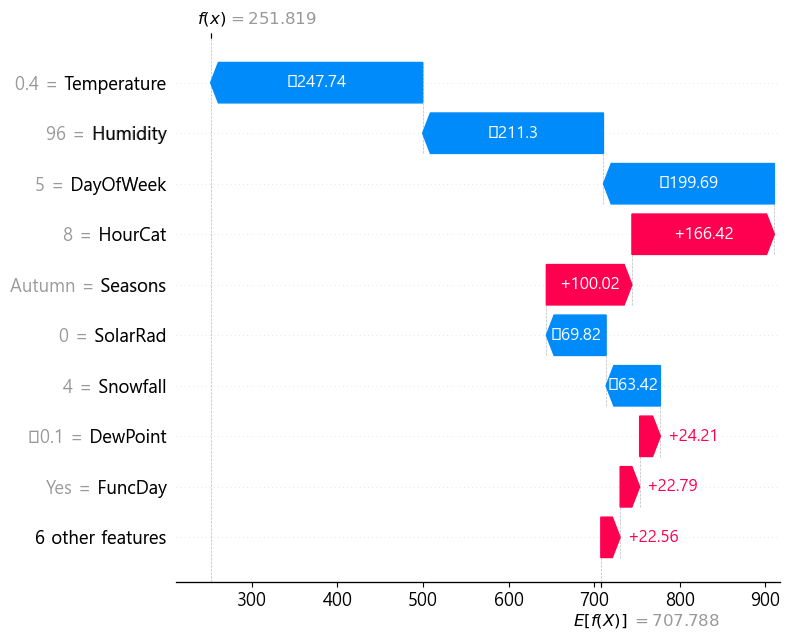

--- 11/27 18시 (평범한 퇴근 러시아워) ---
실제 대여량: 1538  / 예측: 1664.0
주요 날씨: {'Temperature': 10.2, 'Snowfall': 0.0, 'Rainfall': 0.0}


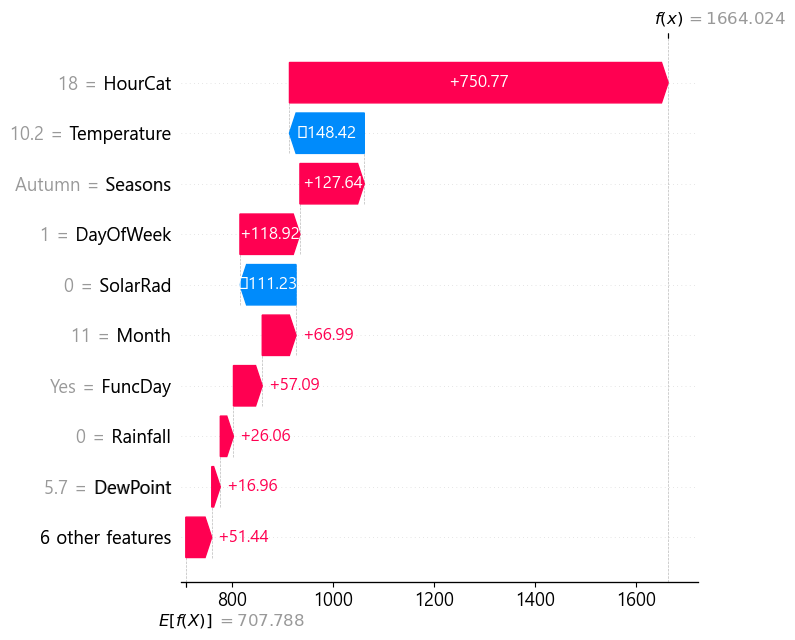

In [21]:
snow_row = te[(te["Date"] == "2018-11-24") & (te["Hour"] == 8)].index[0]
rush_row = te[(te["Date"] == "2018-11-27") & (te["Hour"] == 18)].index[0]

Xte_cat = te.copy()
for c in CAT_CHAMPION:
    Xte_cat[c] = Xte_cat[c].astype("category")

for label, row_idx in [("11/24 08시 (폭설 중)", snow_row), ("11/27 18시 (평범한 퇴근 러시아워)", rush_row)]:
    x_row = Xte_cat.loc[[row_idx], FEAT_CHAMPION]
    sv_row = explainer.shap_values(x_row)
    print(f"--- {label} ---")
    print("실제 대여량:", te.loc[row_idx, "Count"], " / 예측:", round(te.loc[row_idx, "pred"], 1))
    print("주요 날씨:", x_row[["Temperature", "Snowfall", "Rainfall"]].to_dict("records")[0])
    exp = shap.Explanation(sv_row[0], base_values=explainer.expected_value,
                            data=x_row.iloc[0], feature_names=FEAT_CHAMPION)
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

폭설 시간대(11/24 08시)에서는 `Snowfall`(적설)과 낮은 `Temperature`가 예측값을 기준선(base value, 학습셋 평균 예측)보다 크게 끌어내리는 반면, 평범한 퇴근 러시아워(11/27 18시)에서는 `HourCat=18`이 가장 크게 예측을 끌어올리는 걸 직접 확인할 수 있습니다. **모델이 실제로 "왜" 그렇게 예측했는지가 사람이 세운 가설(눈 오면 급감, 퇴근시간엔 급증)과 일치**한다는 걸 SHAP으로 검증한 것입니다.

## 9. 실험 루프 4 — "타겟이 오른쪽으로 치우쳐 있으니 log1p 변환을 쓰면 개선될 것이다" (⚠️ 기각)

**가설**: 2-1절에서 `Count` 분포가 오른쪽으로 크게 치우쳐 있는 걸 봤습니다. 타겟을 `log1p`로 바꿔 학습하고 예측 후 `expm1`로 되돌리면, 극단적으로 큰 값들이 손실 함수에 미치는 영향이 줄어들어 전체적으로 더 안정된 모델이 될 것입니다.

In [22]:
model4, score4, pred4 = run_experiment(
    "exp4_log1p_target", FEAT_CHAMPION, cat_cols=CAT_CHAMPION,
    note="타겟을 log1p로 변환해서 학습 (예측 후 expm1로 복원)", log_target=True)

exp4_log1p_target              RMSE =   118.32   (타겟을 log1p로 변환해서 학습 (예측 후 expm1로 복원))


**결과: 104.32 → 118.32로 오히려 악화.** 가설 **기각**.

**이유 분석**: 이번 대회의 평가지표는 로그 공간이 아니라 **원 단위 RMSE**입니다. `log1p` 변환은 "비율 오차"를 균등하게 만들어주지만, 정작 채점 기준인 원 단위 제곱오차에서는 대여량이 큰 러시아워(1,000~2,000대대)의 오차가 전체 RMSE에 가장 큰 영향을 줍니다. log 공간에서 학습하면 이 큰 값들의 오차에 상대적으로 덜 민감해지므로, 절대적인 관점(RMSE)에서는 오히려 손해를 본 것으로 보입니다. **"분포가 치우쳤다"는 진단은 맞았지만, 그 처방(log 변환)이 이번 평가지표와는 맞지 않았다**는 좋은 예시입니다.

## 10. 실험 루프 5 — "테스트 기간 내부의 추세를 캘린더 피처가 못 잡는다. DayOfYear를 추가하면 개선될 것이다" (⚠️ 기각)

**가설**: 8-1절에서 발견한 "테스트 기간 후반부로 갈수록 과대예측이 심해지는" 편향의 원인으로, `Month`/`Seasons`가 테스트 기간(11월 후반) 내내 같은 값으로 고정되어 기온이 급격히 떨어지는 흐름을 반영하지 못한다고 봤습니다. 1~365 연속값인 `DayOfYear`를 추가하면 이 세밀한 흐름을 잡아 편향이 줄어들 것입니다.

In [23]:
df["DayOfYear"] = df["Date"].dt.dayofyear

model5, score5, pred5 = run_experiment(
    "exp5_add_dayofyear", FEAT_CHAMPION + ["DayOfYear"], cat_cols=CAT_CHAMPION,
    note="DayOfYear(연속형) 추가, Month는 유지")

FEAT5B = ["HourCat", "Temperature", "Humidity", "WindSpeed", "Visibility",
          "DewPoint", "SolarRad", "Rainfall", "Snowfall"] + CATS + ["DayOfWeek", "IsWeekend", "DayOfYear"]
model5b, score5b, pred5b = run_experiment(
    "exp5b_dayofyear_replace_month", FEAT5B, cat_cols=CAT_CHAMPION,
    note="DayOfYear가 Month를 대체 (중복 정보 제거 시도)")

exp5_add_dayofyear             RMSE =   146.28   (DayOfYear(연속형) 추가, Month는 유지)


exp5b_dayofyear_replace_month  RMSE =   114.82   (DayOfYear가 Month를 대체 (중복 정보 제거 시도))


**결과: 둘 다 악화** — `Month`와 같이 넣으면 104.32 → 146.28, `Month`를 대체해도 104.32 → 114.82로 여전히 챔피언보다 나쁩니다. 가설 **기각**.

**이유 분석**: `DayOfYear`는 1~365 사이의 값을 갖는 고카디널리티 연속형 피처인데, 학습 데이터가 8천여 행뿐이라 트리가 이 축을 세밀하게 쪼개다 보면 **`Month`(12개 값)로는 나오지 않던 노이즈까지 학습**하게 됩니다. `Month`와 함께 넣은 exp5가 `Month`를 대체한 exp5b보다도 더 나쁜 걸 보면, 두 피처가 상관된 상태로 함께 있을 때 트리의 분기 자원(feature_fraction 등)을 서로 갉아먹는 효과까지 겹친 것으로 보입니다. "그럴듯한 가설도 실제로 검증해야 한다"는 store_sales 실습과 같은 교훈입니다.

## 11. 실험 루프 6 — "최근 대여 수준을 안전한 시차(safe lag)로 알려주면 잔차를 보정할 것이다" (⚠️ 기각)

**가설**: 대여량은 자기상관이 있을 수 있습니다 — "최근에 얼마나 탔는지"를 알면 날씨만으로 설명 안 되는 수요 수준(신규 가입자 증가, 지역 행사 등)을 보정할 수 있을 것입니다.

**주의(safe lag)**: 이번 테스트는 마지막 14일 전체를 한 번에 예측하는 상황을 가정하므로, `lag_1`(1시간 전 실제값)처럼 테스트 기간 "안"의 값을 참조하는 피처는 실전에서 쓸 수 없는 정보입니다(예측해야 할 미래이기 때문). `store_sales_forecasting.ipynb`에서 다룬 것과 같은 논리로, **테스트 시작 시점보다 최소 336시간(14일) 이전의 값만** 안전하게 사용합니다.

In [24]:
SAFE_LAG = 336  # 14일 = 테스트 기간 길이만큼 최소 시차를 둔다

df["lag_336"] = df["Count"].shift(SAFE_LAG)
df["roll_mean_168_lag336"] = df["Count"].shift(SAFE_LAG).rolling(168, min_periods=24).mean()
df["roll_mean_72_lag336"] = df["Count"].shift(SAFE_LAG).rolling(72, min_periods=24).mean()
LAGS = ["lag_336", "roll_mean_168_lag336", "roll_mean_72_lag336"]

model6, score6, pred6 = run_experiment(
    "exp6_add_safe_lag", FEAT_CHAMPION + ["DayOfYear"] + LAGS, cat_cols=CAT_CHAMPION,
    note="14일 전 lag + rolling mean 추가 (exp5 피처셋 기반)")

model6b, score6b, pred6b = run_experiment(
    "exp6b_lag_only", FEAT_CHAMPION + LAGS, cat_cols=CAT_CHAMPION,
    note="lag/rolling만 추가, DayOfYear는 제외 (효과 분리)")

exp6_add_safe_lag              RMSE =   151.91   (14일 전 lag + rolling mean 추가 (exp5 피처셋 기반))


exp6b_lag_only                 RMSE =   171.44   (lag/rolling만 추가, DayOfYear는 제외 (효과 분리))


**결과: 둘 다 악화** (104.32 → 151.91 / 171.44). 가설 **기각**.

**이유 분석**: `SAFE_LAG=336`은 "정확히 14일 전"을 뜻하는데, 테스트 기간(11/17~11/30)의 14일 전은 11/3~11/16으로 **아직 기온이 비교적 따뜻했던 시기**입니다(8-1절에서 본 급격한 한파 시작 이전). 즉 lag 피처는 "2주 전엔 이만큼 탔다"는, **지금 시점엔 이미 낡은(그리고 방향이 틀린) 상향 신호**를 모델에 주입한 셈입니다. 이는 8-1절에서 발견한 "테스트 후반부 과대예측" 편향과 정확히 같은 방향이라, 오히려 편향을 키운 것으로 보입니다. 트렌드가 급변하는 구간에서는 **"최근"이라는 개념 자체가 안전한 시차 제약 때문에 더 이상 최근이 아니게 될 수 있다**는 걸 보여주는 사례입니다.

## 12. 실험 루프 7 — "test셋으로 반복 튜닝하면 과적합 위험이 있다. train 내부 검증셋으로 제대로 튜닝하자"

지금까지는 매 실험마다 곧바로 테스트셋으로 채점했습니다. 교육용 실습에서는 실험 횟수가 적어 큰 문제가 없었지만, **하이퍼파라미터 탐색처럼 여러 조합을 반복 시도하는 단계**부터는 테스트셋을 반복 조회하는 것 자체가 "테스트셋에 과적합"되는 위험한 습관입니다. 학습 기간(train) 안에서 다시 **가장 최근 14일을 내부 검증셋(internal validation)**으로 떼어 튜닝하고, 최종 설정만 실제 테스트셋으로 딱 한 번 확인합니다.

**가설**: 정규화(L1/L2)를 추가하고 `num_leaves`/`min_data_in_leaf`를 조정하면, 지금까지 쓴 고정 2,000라운드보다 더 일반화가 잘되는 설정을 찾을 수 있을 것이다.

In [25]:
test_start = df["Date"].max() - pd.Timedelta(days=TEST_DAYS - 1)
inner_val_start = test_start - pd.Timedelta(days=14)
inner_train_mask = df["Date"] < inner_val_start
inner_val_mask = (df["Date"] >= inner_val_start) & (df["Date"] < test_start)
print("내부 학습:", inner_train_mask.sum(), "행 / 내부 검증:", inner_val_mask.sum(), "행",
      f"({df.loc[inner_val_mask,'Date'].min().date()} ~ {df.loc[inner_val_mask,'Date'].max().date()})")

def tune(params_list, feature_cols=FEAT_CHAMPION, cat_cols=CAT_CHAMPION):
    tr_i = df.loc[inner_train_mask].copy()
    va_i = df.loc[inner_val_mask].copy()
    for c in cat_cols:
        tr_i[c] = tr_i[c].astype("category")
        va_i[c] = va_i[c].astype("category")
    best = None
    for i, p in enumerate(params_list):
        params = dict(objective="regression", metric="rmse", learning_rate=0.05,
                      num_leaves=31, min_data_in_leaf=20, feature_fraction=0.9,
                      bagging_fraction=0.9, bagging_freq=1, verbose=-1, seed=42,
                      feature_pre_filter=False)
        params.update(p)
        dtr_i = lgb.Dataset(tr_i[feature_cols], label=tr_i["Count"], categorical_feature=list(cat_cols))
        dva_i = lgb.Dataset(va_i[feature_cols], label=va_i["Count"], categorical_feature=list(cat_cols), reference=dtr_i)
        model = lgb.train(params, dtr_i, num_boost_round=3000, valid_sets=[dva_i],
                           callbacks=[lgb.early_stopping(100, verbose=False)])
        pred = np.clip(model.predict(va_i[feature_cols], num_iteration=model.best_iteration), 0, None)
        score = rmse(va_i["Count"], pred)
        print(f"cfg{i}: {p}  ->  내부 검증 RMSE = {score:.2f}  (best_iter={model.best_iteration})")
        if best is None or score < best[0]:
            best = (score, p, model.best_iteration)
    return best

grid = [
    {},
    dict(num_leaves=15, min_data_in_leaf=30),
    dict(num_leaves=63, min_data_in_leaf=10),
    dict(num_leaves=31, min_data_in_leaf=50),
    dict(num_leaves=31, min_data_in_leaf=20, lambda_l1=1.0, lambda_l2=1.0),
    dict(num_leaves=15, min_data_in_leaf=50, learning_rate=0.03, lambda_l2=1.0),
    dict(num_leaves=63, min_data_in_leaf=15, learning_rate=0.03),
]
best_val_score, best_params, best_iter = tune(grid)
print()
print("내부 검증 기준 최적 설정:", best_params, " (RMSE:", round(best_val_score, 2), ", iters:", best_iter, ")")

내부 학습: 8088 행 / 내부 검증: 336 행 (2018-11-03 ~ 2018-11-16)


cfg0: {}  ->  내부 검증 RMSE = 171.43  (best_iter=479)


cfg1: {'num_leaves': 15, 'min_data_in_leaf': 30}  ->  내부 검증 RMSE = 172.81  (best_iter=728)


cfg2: {'num_leaves': 63, 'min_data_in_leaf': 10}  ->  내부 검증 RMSE = 171.08  (best_iter=291)


cfg3: {'num_leaves': 31, 'min_data_in_leaf': 50}  ->  내부 검증 RMSE = 181.47  (best_iter=410)


cfg4: {'num_leaves': 31, 'min_data_in_leaf': 20, 'lambda_l1': 1.0, 'lambda_l2': 1.0}  ->  내부 검증 RMSE = 169.95  (best_iter=380)


cfg5: {'num_leaves': 15, 'min_data_in_leaf': 50, 'learning_rate': 0.03, 'lambda_l2': 1.0}  ->  내부 검증 RMSE = 175.61  (best_iter=947)


cfg6: {'num_leaves': 63, 'min_data_in_leaf': 15, 'learning_rate': 0.03}  ->  내부 검증 RMSE = 180.10  (best_iter=645)

내부 검증 기준 최적 설정: {'num_leaves': 31, 'min_data_in_leaf': 20, 'lambda_l1': 1.0, 'lambda_l2': 1.0}  (RMSE: 169.95 , iters: 380 )


In [26]:
# 최적 설정으로 전체 학습셋을 다시 학습해서, 실제 테스트셋으로 "딱 한 번" 확인
model7, score7, pred7 = run_experiment(
    "exp7_tuned", FEAT_CHAMPION, cat_cols=CAT_CHAMPION,
    note=f"내부 검증으로 고른 설정({best_params}) 적용",
    params=best_params, num_round=best_iter)

exp7_tuned                     RMSE =   112.22   (내부 검증으로 고른 설정({'num_leaves': 31, 'min_data_in_leaf': 20, 'lambda_l1': 1.0, 'lambda_l2': 1.0}) 적용)


**결과**: 내부 검증셋에서는 정규화를 추가한 설정이 근소하게 더 좋았지만(169.95 vs 기본값 171.43), 정작 **실제 테스트셋에서는 112.22로 챔피언(104.32)보다 나쁩니다.** 가설 자체(제대로 된 방법론으로 튜닝하면 나아질 것이다)는 **기각**됐지만, 튜닝 절차 자체는 다음 사이클에서도 재사용할 가치가 있습니다.

**이유 분석**: 내부 검증 구간(11/3~11/16)은 테스트 구간(11/17~11/30) "바로 직전"이라 가장 합리적인 대리 구간처럼 보였지만, 실제로는 테스트 구간에서 벌어진 **급격한 한파(비정상성/regime shift)**를 내부 검증 구간은 아직 겪지 않은 상태였습니다. 즉 "가장 최근 데이터로 검증한다"는 원칙이 정석이긴 해도, **날씨처럼 짧은 기간에도 국면이 바뀌는 데이터에서는 완벽한 안전장치가 아닐 수 있다**는 걸 보여줍니다. 그렇다고 해서 "test셋으로 직접 반복 튜닝해도 된다"는 뜻은 아닙니다 — 그건 대회 실전에서는 아예 불가능한 방법(실제 정답을 모름)이고, 지금 우리가 test셋을 여러 번 들여다본 것 자체가 이미 이상적인 절차는 아니라는 점도 함께 기억해야 합니다.

## 13. 최종 모델 확정

7번의 실험 루프를 거치는 동안 **exp3(Hour 범주형 처리)**가 유일하게, 그리고 지속적으로 최고 성능(RMSE 104.32)을 유지했습니다. 이후의 모든 시도(로그 변환, 추세 피처, lag 피처, 하이퍼파라미터 튜닝)는 그럴듯한 가설에서 출발했지만 실제로는 성능을 악화시켰습니다. 따라서 **exp3를 최종 모델로 채택**합니다.

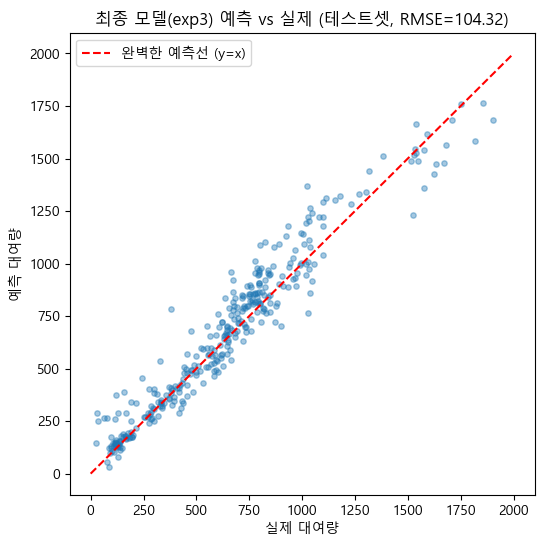

잔여 오차가 가장 큰 시간대 Top 10:
           Date  Hour  Count         pred  Temperature  Rainfall  Snowfall
8519 2018-11-20    23    378   781.787134          9.3       0.0       0.0
8683 2018-11-27    19   1023  1368.650043          9.3       0.0       0.0
8679 2018-11-27    15    666   960.886915         12.5       0.0       0.0
8648 2018-11-26     8   1524  1229.249957          2.0       0.0       0.3
8673 2018-11-27     9    800  1090.519090          5.0       0.0       0.0
8684 2018-11-27    20    825  1103.457792          8.3       0.0       0.0
8464 2018-11-18    16   1026   764.501961          9.4       0.0       0.0
8599 2018-11-24     7     30   290.103436          1.2       0.0       1.3
8520 2018-11-21     0    119   374.271863          7.2       0.2       0.0
8702 2018-11-28    14    675   920.076915         10.3       0.0       0.0


In [27]:
te = df.loc[test_mask].copy()
te["pred"] = pred3

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(te["Count"], te["pred"], alpha=0.4, s=15)
lims = [0, max(te["Count"].max(), te["pred"].max()) * 1.05]
ax.plot(lims, lims, "r--", label="완벽한 예측선 (y=x)")
ax.set_xlabel("실제 대여량")
ax.set_ylabel("예측 대여량")
ax.set_title(f"최종 모델(exp3) 예측 vs 실제 (테스트셋, RMSE={score3:.2f})")
ax.legend()
plt.show()

print("잔여 오차가 가장 큰 시간대 Top 10:")
te["abs_err"] = (te["pred"] - te["Count"]).abs()
print(te.sort_values("abs_err", ascending=False)[["Date", "Hour", "Count", "pred", "Temperature", "Rainfall", "Snowfall"]].head(10))

남은 오차의 상당수는 여전히 급격한 기온 하강·강수/적설이 겹치는 시간대에 몰려 있습니다. 날씨 자체의 순간적인 변동성(체감 냉기, 갑작스런 눈)까지 완벽히 잡아내긴 어렵다는 걸 보여주는데, 이는 다음 개선 아이디어로 이어집니다(14절 회고 참고).

## 14. 결과 정리 — RMSE는 어떻게 감소했는가

In [28]:
summary = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
summary

,실험,RMSE,설명
0,exp3_hour_as_category,104.32,Hour를 수치형이 아닌 범주형(category)으로 처리
1,exp7_tuned,112.22,"내부 검증으로 고른 설정({'num_leaves': 31, 'min_data_in_..."
2,exp5b_dayofyear_replace_month,114.82,DayOfYear가 Month를 대체 (중복 정보 제거 시도)
3,exp4_log1p_target,118.32,타겟을 log1p로 변환해서 학습 (예측 후 expm1로 복원)
4,exp2_add_calendar,138.88,DayOfWeek/Month/IsWeekend 달력 피처 추가
5,exp5_add_dayofyear,146.28,"DayOfYear(연속형) 추가, Month는 유지"
6,exp6_add_safe_lag,151.91,14일 전 lag + rolling mean 추가 (exp5 피처셋 기반)
7,exp6b_lag_only,171.44,"lag/rolling만 추가, DayOfYear는 제외 (효과 분리)"
8,exp1_add_categoricals,228.93,Seasons/Holiday/FuncDay 범주형 피처 추가
9,(진단) Hour만 사용,254.41,원시 날씨 피처를 다 빼고 Hour 하나만


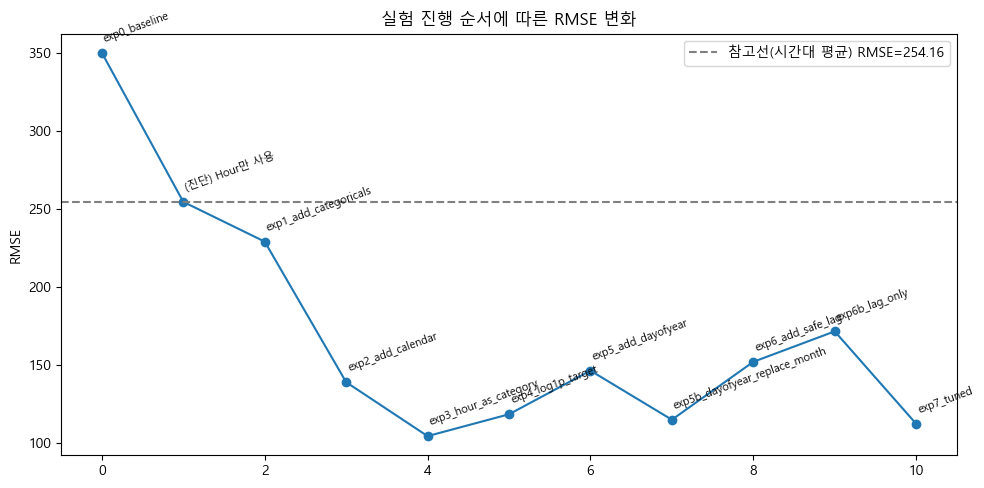

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
order = pd.DataFrame(results)
ax.plot(range(len(order)), order["RMSE"], marker="o")
for i, row in order.iterrows():
    ax.annotate(row["실험"], (i, row["RMSE"]), textcoords="offset points", xytext=(0, 8), fontsize=8, rotation=20)
ax.axhline(254.16, color="gray", linestyle="--", label="참고선(시간대 평균) RMSE=254.16")
ax.set_ylabel("RMSE")
ax.set_title("실험 진행 순서에 따른 RMSE 변화")
ax.legend()
plt.tight_layout()
plt.show()

| # | 실험 | RMSE | 판정 |
|---|---|---|---|
| - | naive: 시간대 평균 | 254.16 | 참고선 |
| 0 | baseline (Hour + 원시 날씨) | 349.90 | 참고선보다도 나쁨 |
| 1 | + Seasons/Holiday/FuncDay | 228.93 | ✅ 채택 |
| 2 | + 캘린더(요일/월/주말) | 138.88 | ✅✅ 가장 큰 개선 |
| 3 | Hour를 범주형으로 처리 | **104.32** | ✅ **최종 채택 (챔피언)** |
| 4 | log1p 타겟 변환 | 118.32 | ❌ 기각 |
| 5 | DayOfYear 추세 피처 | 146.28 / 114.82 | ❌ 기각 |
| 6 | Safe-lag(14일 전) 피처 | 151.91 / 171.44 | ❌ 기각 |
| 7 | 하이퍼파라미터 튜닝(내부 검증) | 112.22 | ❌ 기각 |

**베이스라인(349.90) 대비 최종 모델(104.32)은 RMSE를 약 70% 줄였고, 참고선(254.16) 대비로도 약 59% 개선**했습니다. 다만 이 개선의 대부분은 3번의 "채택된" 실험(1~3번)에서 나왔고, 그 이후 시도한 4번의 실험은 모두 그럴듯한 가설에서 출발했음에도 기각됐다는 점이 중요합니다.

### 잘 먹힌 것
1. **범주형 맥락 정보(Seasons/Holiday/FuncDay)**: 원시 날씨만으론 트리가 오히려 혼란스러워했는데(349.90, 참고선보다도 나쁨), 맥락을 주자 큰 폭으로 개선(228.93).
2. **달력 피처(요일/월/주말)**: 가장 큰 개선(228.93 → 138.88). 계절 대분류가 놓치는 세부 패턴을 보완.
3. **Hour의 범주형 처리**: 이중 피크를 가진 비선형 패턴을 트리가 더 유연하게 다루도록 해준 결정적 한 수(138.88 → 104.32).

### 안 먹힌 것 (그리고 왜)
1. **log1p 타겟 변환**: "분포가 치우쳤다"는 진단은 맞았지만, 채점 기준(원 단위 RMSE)과 맞지 않는 처방이었다.
2. **DayOfYear 추세 피처**: 고카디널리티 연속형 피처가 적은 데이터(8천여 행)에서 오히려 노이즈로 작용, `Month`와 중복되며 트리 분기를 흐트러뜨렸다.
3. **Safe-lag 피처**: 안전한 시차(14일)를 지키려다 보니, 정작 참조한 "과거"가 이미 다른 날씨 국면(더 따뜻했던 시기)이라 방향이 틀린 신호를 줬다.
4. **하이퍼파라미터 튜닝**: 방법론(내부 검증셋 분리)은 올바르지만, 짧은 기간에 날씨 국면이 급변하는 이 데이터에서는 "가장 최근 구간"조차 완벽한 검증 대리자가 되지 못했다.

### XAI로 확인한 것
- 전역 중요도: `HourCat`, `Temperature`가 압도적 1·2위. `DewPoint`는 `Temperature`와 상관 0.91이라 중요도를 나눠 가짐.
- 개별 예측 설명(SHAP waterfall): 폭설 시간대는 `Snowfall`·낮은 `Temperature`가, 퇴근 러시아워는 `HourCat`이 예측을 각각 정반대 방향으로 크게 움직인다는 걸 확인 — 사람이 세운 가설과 모델의 실제 판단 근거가 일치함을 검증했다.

### 다음에 시도해볼 것
- `Temperature × HourCat` 같은 명시적 상호작용 피처(트리가 자동으로 학습하긴 하지만, 데이터가 적을 때는 명시적으로 주는 게 도움이 될 수 있음).
- 체감온도(wind chill) 같은 물리 기반 파생 피처.
- 여러 연도 데이터를 확보해 `DayOfYear`/`lag` 계열 피처를 다시 시도 — 지금 실패 원인(데이터 부족, 국면 전환)이 데이터가 늘어나면 해소될 수 있는지 확인.
- 예측 구간(prediction interval)을 함께 제공하는 quantile regression — 폭설처럼 큰 오차가 나는 상황을 "이 정도는 불확실하다"고 미리 알려주는 방향.